# 13 · Visualization gallery for the future local app

A compact gallery showing the plot families that structured Ruddy outputs can support. This notebook is intentionally presentation-oriented and acts as a visual requirements reference for later product design.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_bivariate, analyze_groups, analyze_factorial, analyze_pca, analyze_anomalies, analyze_representation_similarity
frame,dataset=load_tabular_demo(); A=load_feature_demo('representation_a'); B=load_feature_demo('representation_b')
biv=analyze_bivariate(dataset); grp=analyze_groups(dataset,responses=('activity',),groups=('group',)); fac=analyze_factorial(dataset,response='activity',factors=('group','source'),interactions=(('group','source'),)); pca=analyze_pca(A,n_components=3,scaling='standard'); an=analyze_anomalies(A,methods=('isolation_forest','lof'),random_state=42); rep=analyze_representation_similarity(A,B,cca_components=3,mantel_permutations=19,random_state=42)

## Distribution family

findfont: Failed to find font weight semibold, now using 700.


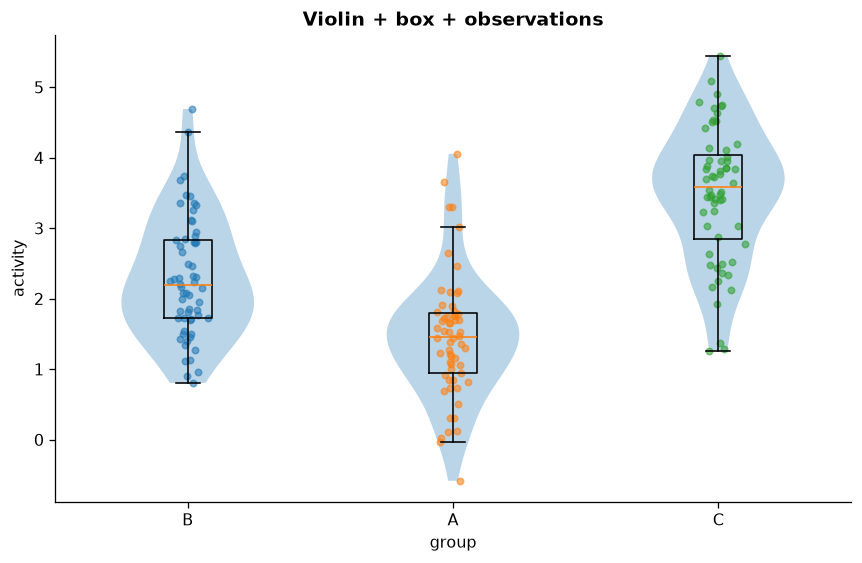

In [2]:
group_violin_box_scatter(frame,value='activity',group='group',title='Violin + box + observations'); plt.show()

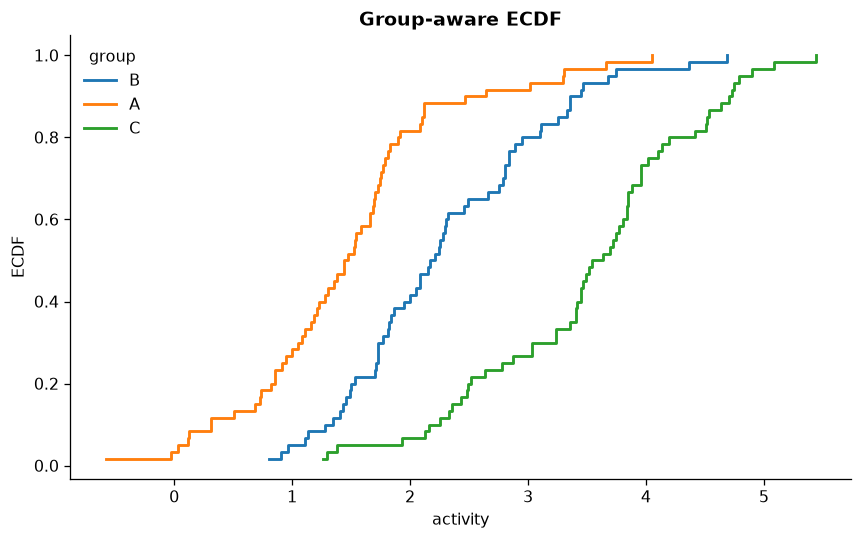

In [3]:
ecdf_by_group(frame,value='activity',group='group',title='Group-aware ECDF'); plt.show()

## Relationship family

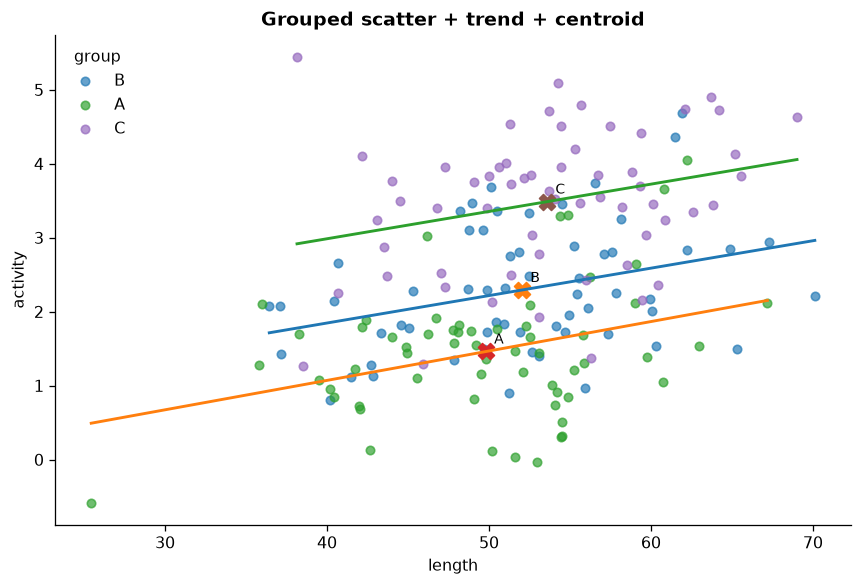

In [4]:
scatter_by_group(frame,x='length',y='activity',group='group',title='Grouped scatter + trend + centroid'); plt.show()

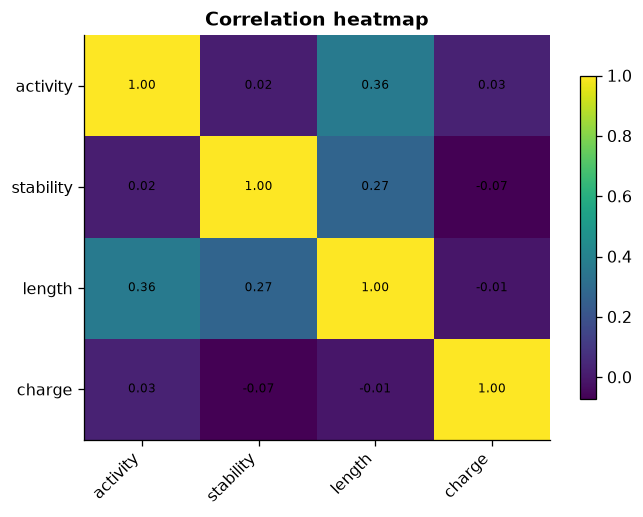

In [5]:
num=['activity','stability','length','charge']; pear=biv.correlations.query('method=="pearson" and status=="ok"'); M=pd.DataFrame(np.eye(len(num)),index=num,columns=num);
for _,r in pear.iterrows():
    if r.column_x in num and r.column_y in num: M.loc[r.column_x,r.column_y]=M.loc[r.column_y,r.column_x]=r.coefficient
matrix_heatmap(M,title='Correlation heatmap'); plt.show()

## Group and factorial family

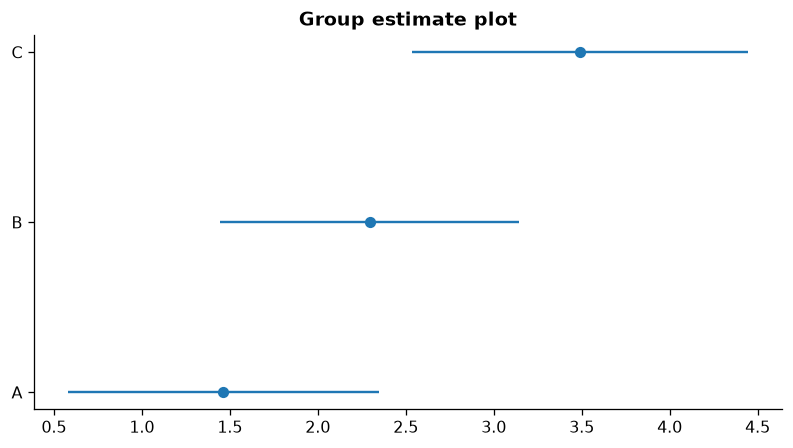

In [6]:
s=grp.numeric_summaries.query('response=="activity"'); fig,ax=plt.subplots(figsize=(7,4)); ax.errorbar(s['mean'],np.arange(len(s)),xerr=s['std'],fmt='o'); ax.set_yticks(np.arange(len(s)),s.group_level.astype(str)); ax.set_title('Group estimate plot'); finish(fig); plt.show()

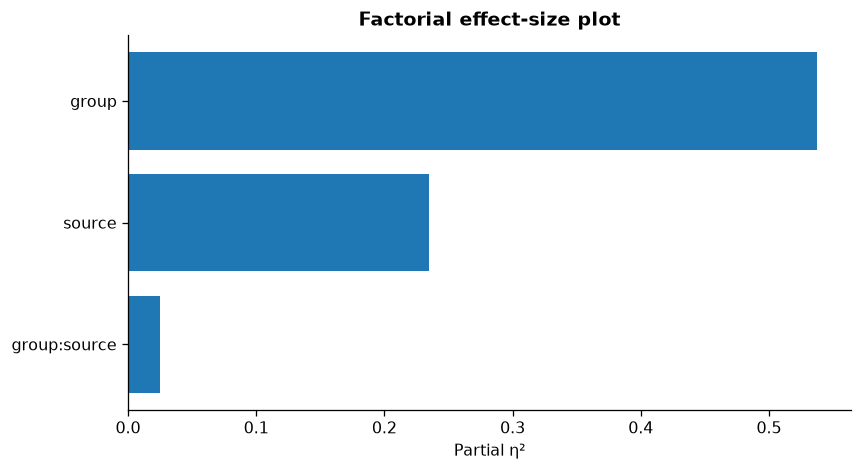

In [7]:
e=fac.effects.query('status=="ok"'); bar_metric(e,label='term',value='partial_eta_squared',title='Factorial effect-size plot',ylabel='Partial η²'); plt.show()

## Projection and representation family

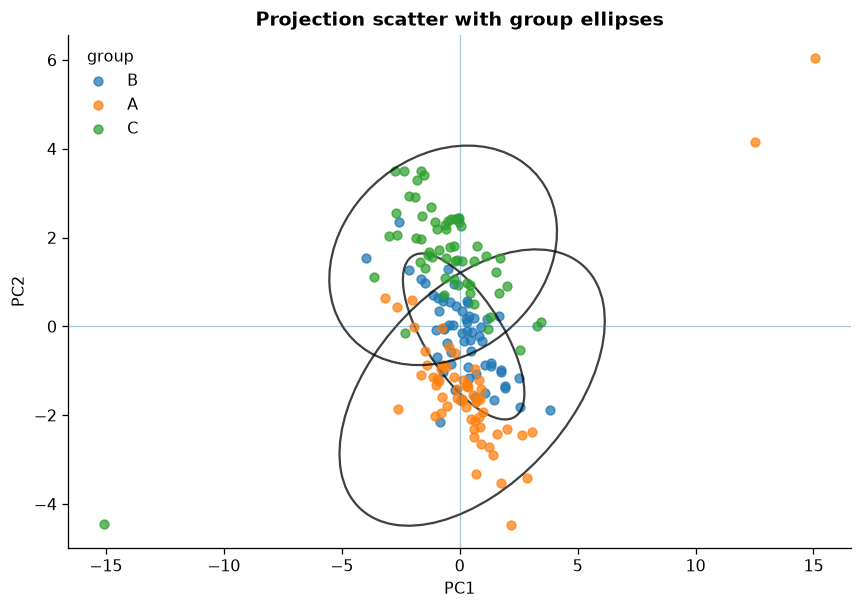

In [8]:
score_plot(pca.scores,frame,x='PC1',y='PC2',group='group',title='Projection scatter with group ellipses',ellipses=True); plt.show()

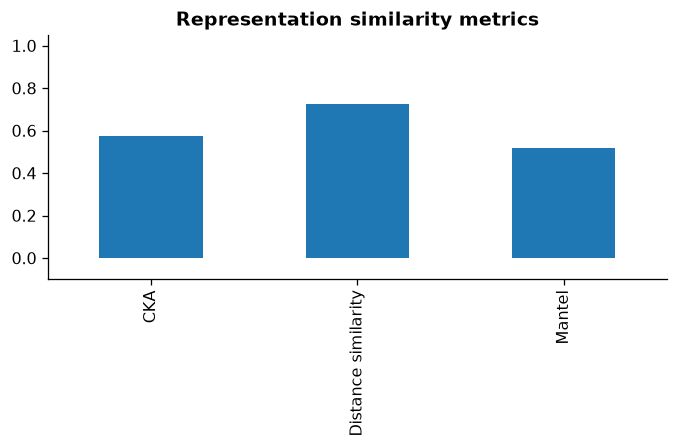

In [9]:
vals=pd.Series({'CKA':rep.cka.iloc[0].cka,'Distance similarity':rep.distance_similarity.iloc[0].coefficient,'Mantel':rep.mantel.iloc[0].correlation}); fig,ax=plt.subplots(figsize=(6,4)); vals.plot(kind='bar',ax=ax); ax.set_ylim(-.1,1.05); ax.set_title('Representation similarity metrics'); finish(fig); plt.show()

## Anomaly family

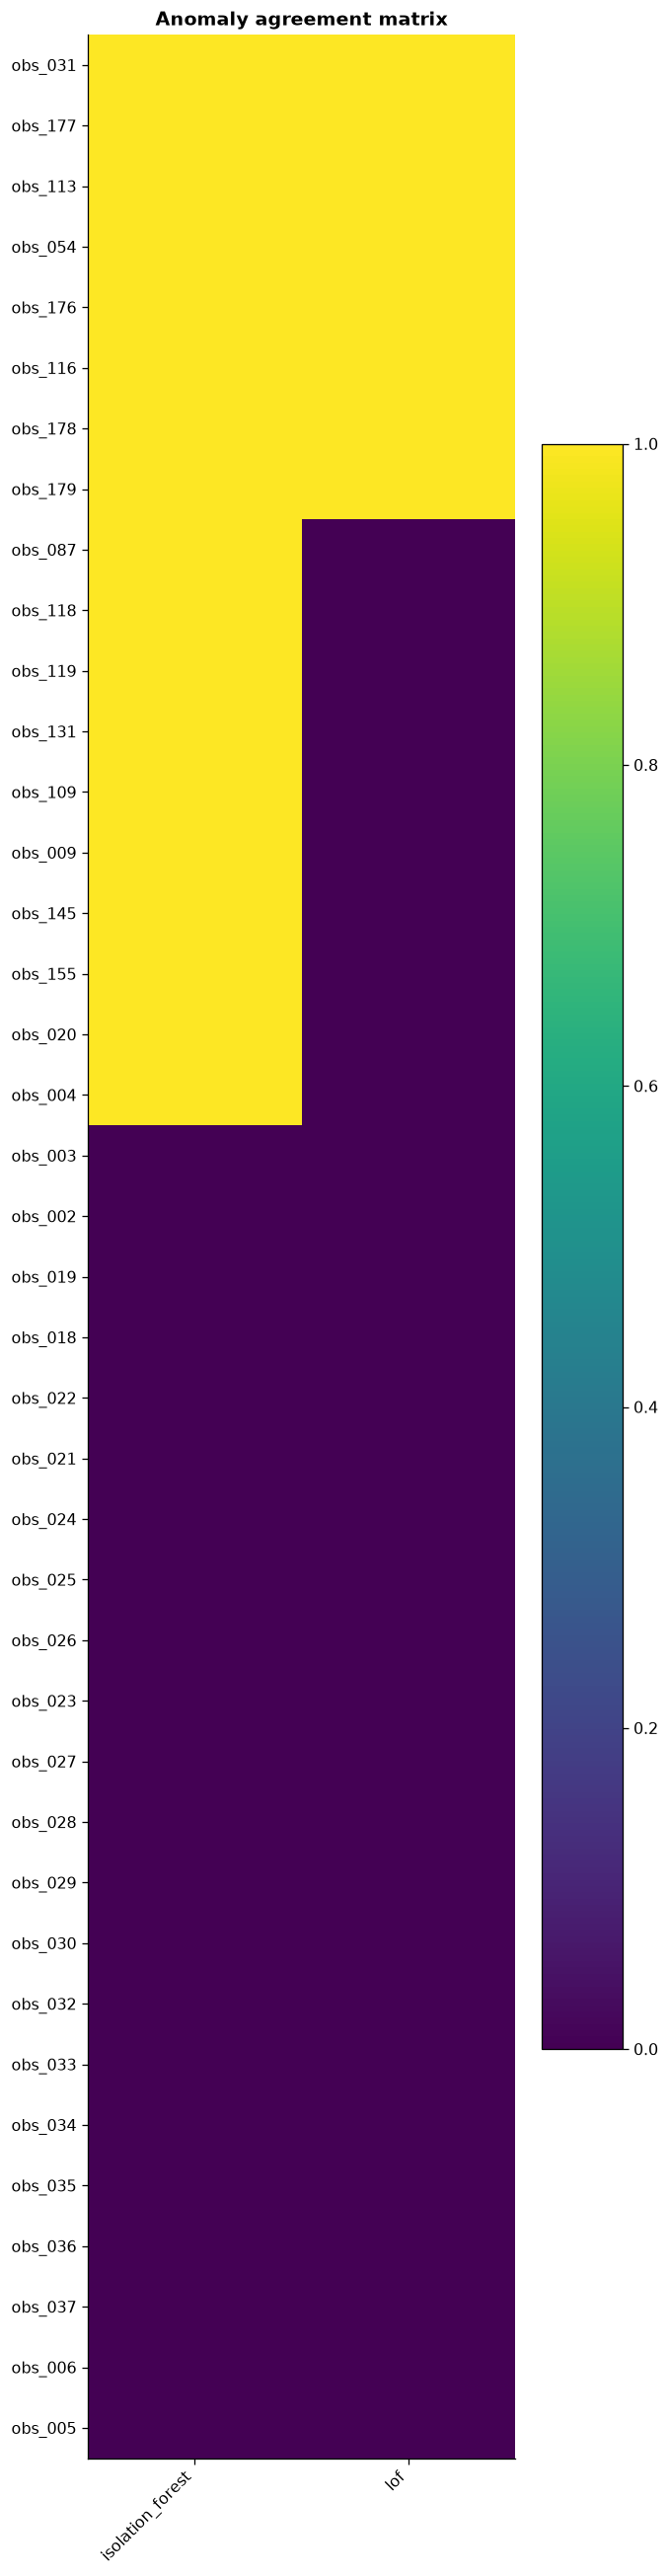

In [10]:
anomaly_agreement(an.scores,title='Anomaly agreement matrix'); plt.show()

### Visual contract
These figures are downstream views of structured results. A future local application can reproduce the same plot families without adding visualization dependencies to the Ruddy core.